# Notebook 1 – California Housing (Regression)

## Overview
We benchmark six tabular-learning methods on the California Housing dataset:
**Tabular ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest** and **Ridge Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **RMSE**, **MAE**, **R²**.

> **Adaptation note:** The FT-Transformer and Tabular ResNet implementations in this notebook
> have been adapted to follow Gorishniy et al., 2021 (https://github.com/yandex-research/rtdl):
>
> - **Tabular ResNet**: uses `rtdl_revisiting_models.ResNet` directly (via a thin wrapper) with
>   separate `dropout1` / `dropout2` and a `d_hidden_multiplier` to compute the inner hidden
>   dimension, matching the paper's architecture exactly.
> - **FT-Transformer**: uses `model.make_parameter_groups()` with AdamW so that embedding layers,
>   normalisation layers and biases are excluded from weight-decay regularisation, as prescribed
>   in the paper.


## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math
import json
import random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from rtdl_revisiting_models import ResNet as _RTDLResNet
from rtdl_revisiting_models import FTTransformer
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import time
import io
from pytorch_tabnet.tab_model import TabNetRegressor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## Configuration
These parameters denote the key parameters for the experiments.
- SEEDS: Set 3 specific seed numbers
- N_OPTUNA_TRIALS: Number of trials to run for Optuna hyperparameter tuning
- TEST_SIZE: Proportion of data used for train-test split
- VAL_FRAC: Proportion of training data divided into train-validation (effectively 60/20/20 for train/val/test split)
- N_PATIENCE: Number of trials for early stopping when validation performance stops improving
- OPT_EPOCHS: Number of epochs to run for Optuna hyperparameter tuning
- TR_EPOCHS: Number of epochs to run when training across seeds
- N_BATCH_SIZE: Number of mini-batches used when training neural network models

In [2]:
SEEDS          = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25 
N_PATIENCE      = 10
OPT_EPOCHS      = 50
TR_EPOCHS       = 100
N_BATCH_SIZE    = 1024


## Data Loading & EDA
- Load dataset from scikit-learn.
- Inspect shape and data types. Generate statistical summary and check for missing values.

In [3]:
data = fetch_california_housing(as_frame=True)
df   = data.frame

print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())


Shape: (20640, 9)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


- No missing values. All features are numeric.

In [4]:
# Show summary statistics of the dataset
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

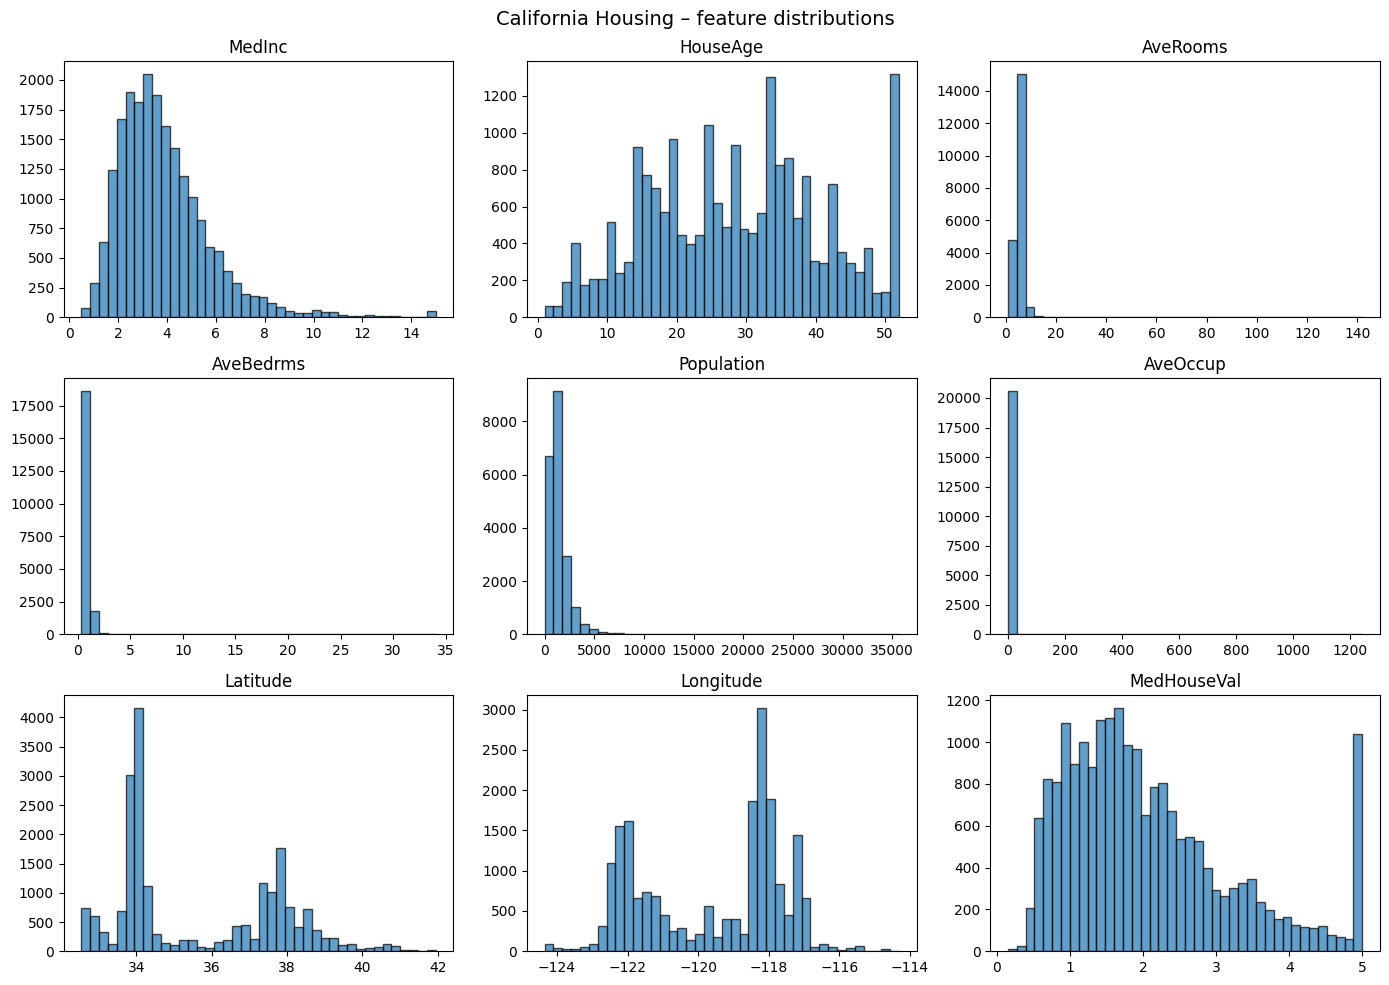

In [5]:
# Plot bar plots of all features to see their distributions and scales.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, edgecolor='k', alpha=0.7)
    axes[i].set_title(col)
plt.suptitle("California Housing – feature distributions", fontsize=14)
plt.tight_layout()
plt.show()


- The features have very different scales and skew. Some features have heavy-tailed distributions (e.g. Population, AveOccup, AveRooms)

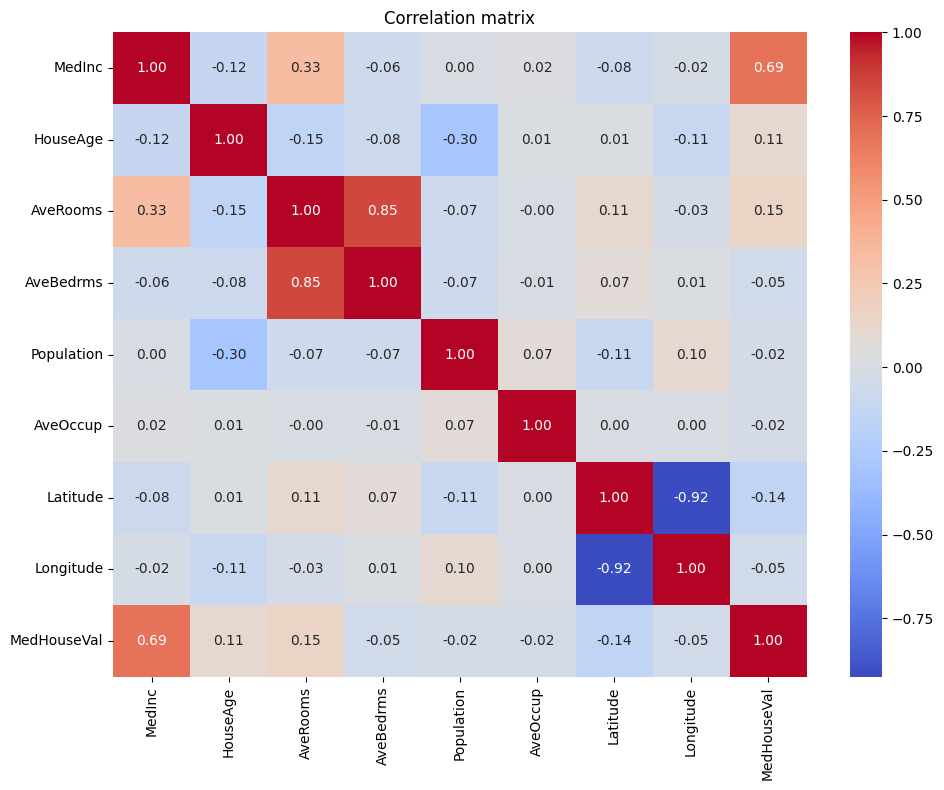

In [6]:
# Plot correlation matrix to see relationships between features and target.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


- There are no particular strongly correlated features > 0.9 except for Latitude and Longitude which represent geographical coordinates and is not necessary for removal.

## Preprocessing
- Extract features and target from dataset

In [7]:
feature_cols = [c for c in df.columns if c != 'MedHouseVal']
target_col   = 'MedHouseVal'

X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)


## Data Splitting (60 / 20 / 20)
- Split data into training, validation and test sets.
- Standardise features using StandardScaler for Deep Learning and Ridge regression models.

In [8]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, random_state=42)

# Standardize features (zero mean, unit variance) for Deep Learning and Ridge regression models.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train_sc.shape}, Val: {X_val_sc.shape}, Test: {X_test_sc.shape}")

Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)


## Helper Functions
- Set random seeds for reproducibility across NumPy, PyTorch, and CUDA.
- Define regression metrics: RMSE, MAE and Rsquared
- Implement generic training and prediction functions for deep learning models.
- Define PhaseTimer object to record modelling time.

In [9]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Metric computation function for regression tasks
def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Training loop for deep learning regression models with early stopping.
# Supports both ResNet (rtdl_revisiting_models.ResNet wrapper) and FT-Transformer.
# For FT-Transformer, uses model.make_parameter_groups() so that embedding /
# normalisation layers and biases are excluded from weight decay, as in
# Gorishniy et al., 2021.
def train_dl_models_num(
    model, X_num_tr, X_cat_tr, y_tr,
    X_num_v, X_cat_v, y_v,
    lr=1e-3, n_epochs=TR_EPOCHS, batch_size=N_BATCH_SIZE,
    device_='cpu'
):
    model = model.to(device_)
    # Use make_parameter_groups() for FT-Transformer (Gorishniy et al., 2021)
    if hasattr(model, 'make_parameter_groups'):
        optimizer = optim.AdamW(model.make_parameter_groups(), lr=lr, weight_decay=1e-5)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    X_num_tr_t = torch.as_tensor(X_num_tr, dtype=torch.float32)
    y_tr_t     = torch.as_tensor(y_tr, dtype=torch.float32)
    X_num_v_t  = torch.as_tensor(X_num_v, dtype=torch.float32)
    y_v_t      = torch.as_tensor(y_v, dtype=torch.float32)

    train_losses, val_losses = [], []
    best_val   = float('inf')
    best_state = None
    patience   = N_PATIENCE
    pat_cnt    = 0

    for epoch in range(n_epochs):
        model.train()
        n   = len(X_num_tr_t)
        idx = torch.randperm(n)

        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b  = idx[i:i + batch_size]
            xn = X_num_tr_t[b].to(device_)
            yb = y_tr_t[b].to(device_)

            optimizer.zero_grad()
            out  = model(xn, None).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            ep_loss += loss.item() * len(b)

        model.eval()
        with torch.no_grad():
            vout  = model(X_num_v_t.to(device_), None).squeeze(-1)
            vloss = criterion(vout, y_v_t.to(device_)).item()

        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val   = vloss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt    = 0
        else:
            pat_cnt += 1

        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses

# Prediction function for deep learning regression models
def predict_dl_models_num(model, X_num, X_cat, device_, batch_size=512):
    model.eval()
    model   = model.to(device_)
    X_num_t = torch.as_tensor(X_num, dtype=torch.float32)
    preds   = []

    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn  = X_num_t[i:i + batch_size].to(device_)
            out = model(xn, None).squeeze(-1)
            preds.append(out.cpu().numpy())

    return np.concatenate(preds)

class PhaseTimer:
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start = {}

    def start(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self._start[phase] = time.perf_counter()

    def stop(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0) + 1

    def get_total(self, phase):
        return self._totals.get(phase, 0.0)

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label=''):
        total = sum(self._totals.values())
        print(f"\n--- Bottleneck Report {label} ---")
        for k, v in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct = 100 * v / total if total > 0 else 0.0
            avg = 1000 * v / self._counts[k]
            print(f"{k:<20} {v:.3f}s ({pct:.1f}%) avg {avg:.2f} ms")
        print(f"TOTAL: {total:.3f}s\n")


In [10]:
# Instantiate key variables for results and timing
all_results    = []
timing_results = []

# Initialize the phase timer for measuring training and inference times
timer = PhaseTimer()

# Model Training
2 Deep Learning models and 4 Classical Baseline models are trained to evaluate their comparative performance. The following steps are carried out equally for each experiment to ensure fairness as much as possible:
1. An Optuna tuning step is performed for hyperparameter tuning to find the best set of hyperparameters.
2. At each step, models are training using the training set and evaluated on the validation set to return the RMSE score.
3. The Optuna trial with the best RMSE score defines the best set of hyperparameters.
4. The models are trained with different seeds to evaluate the impact of randomness on model variability.
5. Statistics on scoring metrics, latency and model size are collected for subsequent analysis.

## Model 1: Tabular ResNet

Adapted from Gorishniy et al., 2021. Uses `rtdl_revisiting_models.ResNet` directly via a thin
wrapper that exposes the `(x_num, x_cat=None)` calling convention consistent with FT-Transformer.
Key differences from a hand-rolled ResNet:
- Two independent dropout rates (`dropout1` after the first linear, `dropout2` after the second).
- `d_hidden = d_block × d_hidden_multiplier` (inner hidden dim is wider than the residual dim).
- Head: `BatchNorm → ReLU → Linear` exactly as in the paper.


In [11]:
# ResNetNumeric wraps rtdl_revisiting_models.ResNet and provides the
# (x_num, x_cat=None) calling convention so that both ResNet and FT-Transformer
# can be driven by the same training loop (Gorishniy et al., 2021).
class ResNetNumeric(nn.Module):
    """Thin wrapper around rtdl_revisiting_models.ResNet.

    Exposes a (x_num, x_cat=None) forward signature so that the same
    training/prediction loop can be used for both ResNet and FT-Transformer.
    The ResNet architecture follows Gorishniy et al., 2021 exactly:
      Input → Linear → [Block ×n] → Output
      Block : BatchNorm → Linear(d_block→d_hidden) → ReLU → Dropout1
                        → Linear(d_hidden→d_block) → Dropout2 → + (residual)
      Output: BatchNorm → ReLU → Linear → (d_out)
    with d_hidden = d_block × d_hidden_multiplier.
    """
    def __init__(self, n_num_features, d_block=128, n_blocks=3,
                 d_hidden_multiplier=2.0, dropout1=0.1, dropout2=0.0):
        super().__init__()
        self.resnet = _RTDLResNet(
            d_in=n_num_features,
            d_out=1,
            n_blocks=n_blocks,
            d_block=d_block,
            d_hidden=None,                       # computed from d_block * d_hidden_multiplier
            d_hidden_multiplier=d_hidden_multiplier,
            dropout1=dropout1,
            dropout2=dropout2,
        )

    def forward(self, x_num, x_cat=None):
        return self.resnet(x_num)


In [12]:
n_num = X_train_sc.shape[1]

# Optuna objective function for TabularResNet hyperparameter tuning
# Search space mirrors the tuning grid used in Gorishniy et al., 2021.
def resnet_reg_objective(trial):

    d_block             = trial.suggest_categorical('d_block', [64, 128, 256])
    d_hidden_multiplier = trial.suggest_float('d_hidden_multiplier', 1.0, 4.0)
    n_blocks            = trial.suggest_int('n_blocks', 1, 6)
    dropout1            = trial.suggest_float('dropout1', 0.0, 0.5)
    dropout2            = trial.suggest_float('dropout2', 0.0, 0.5)
    lr                  = trial.suggest_float('lr', 1e-4, 3e-3, log=True)

    set_seed(42)

    model = ResNetNumeric(
        n_num_features=n_num,
        d_block=d_block,
        n_blocks=n_blocks,
        d_hidden_multiplier=d_hidden_multiplier,
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_dl_models_num(
        model,
        X_train_sc, None, y_train,
        X_val_sc,   None, y_val,
        lr=lr,
        n_epochs=OPT_EPOCHS,
        batch_size=N_BATCH_SIZE,
        device_=str(device),
    )

    preds = predict_dl_models_num(model, X_val_sc, None, str(device))
    rmse  = np.sqrt(mean_squared_error(y_val, preds))

    print(f"Trial {trial.number + 1}: RMSE={rmse:.4f}")

    return rmse

timer.start("optuna")

study_resnet = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_resnet.optimize(resnet_reg_objective, n_trials=N_OPTUNA_TRIALS)

timer.stop("optuna")

best_resnet = study_resnet.best_params
print("Trials done:", len(study_resnet.trials))
print("Best RMSE:", study_resnet.best_value)
print("Best ResNet params:", best_resnet)


Trial 1: RMSE=0.5583
Trial 2: RMSE=0.5822
Trial 3: RMSE=0.5700
Trial 4: RMSE=0.5824
Trial 5: RMSE=0.5635
Trial 6: RMSE=0.5602
Trial 7: RMSE=0.5668
Trial 8: RMSE=0.5720
Trial 9: RMSE=0.8216
Trial 10: RMSE=0.5734
Trial 11: RMSE=0.5594
Trial 12: RMSE=0.5687
Trial 13: RMSE=0.5584
Trial 14: RMSE=0.6178
Trial 15: RMSE=0.5448
Trial 16: RMSE=0.5608
Trial 17: RMSE=0.5377
Trial 18: RMSE=0.5398
Trial 19: RMSE=0.5373
Trial 20: RMSE=0.5702
Trials done: 20
Best RMSE: 0.5372782216405803
Best ResNet params: {'d_block': 256, 'd_hidden_multiplier': 2.0545649743996357, 'n_blocks': 4, 'dropout1': 0.32615651524304806, 'dropout2': 0.2034684367707878, 'lr': 0.0007251689581777987}


In [13]:
# Train TabularResNet across multiple seeds using the best hyperparameters found by Optuna
print("Training Tabular ResNet across seeds...")
resnet_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = ResNetNumeric(
        n_num_features=n_num,
        d_block=best_resnet['d_block'],
        n_blocks=best_resnet['n_blocks'],
        d_hidden_multiplier=best_resnet['d_hidden_multiplier'],
        dropout1=best_resnet['dropout1'],
        dropout2=best_resnet['dropout2'],
    )

    timer.start("train")
    model, tr_l, va_l = train_dl_models_num(
        model,
        X_train_sc, None, y_train,
        X_val_sc,   None, y_val,
        lr=best_resnet['lr'],
        n_epochs=TR_EPOCHS,
        batch_size=N_BATCH_SIZE,
        device_=str(device),
    )
    timer.stop("train")

    resnet_train_curves[seed] = (tr_l, va_l)

    timer.start("inference")
    preds = predict_dl_models_num(model, X_test_sc, None, str(device))
    timer.stop("inference")

    batch_latency      = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_sc)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)

    all_results.append({
        "method": "Tabular ResNet",
        "seed":   seed,
        "rmse":   rmse,
        "mae":    mae,
        "r2":     r2,
    })

    rn_model_last = model
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, "
          f"batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training Tabular ResNet across seeds...
  Seed 42: RMSE=0.5395, MAE=0.3629, R2=0.7779, batch latency=0.01s, per-sample latency=1.42e-06s
  Seed 123: RMSE=0.5289, MAE=0.3536, R2=0.7865, batch latency=0.01s, per-sample latency=2.86e-06s
  Seed 456: RMSE=0.5585, MAE=0.3787, R2=0.7620, batch latency=0.02s, per-sample latency=4.39e-06s


In [14]:
# Tabular ResNet Model Size
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 ** 2)
print(f"Tabular ResNet model size: {size_mb:.2f} MB")

# Compute the total number of parameters in the Tabular ResNet model
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

Tabular ResNet model size: 4.16 MB
Total parameters: 1,083,445


In [15]:
# TabularResNet Timing Report
optuna_time = timer.get_total("optuna")
train_time     = timer.get_total("train")
inference_time = timer.get_total("inference")

timing_results.append({
    "method":         "TabularResNet",
    "optuna_time":    optuna_time,
    "train_time":     train_time,
    "inference_time": inference_time,
})
timer.report("TabularResNet")



--- Bottleneck Report TabularResNet ---
optuna               33.773s (81.7%) avg 33773.18 ms
train                7.545s (18.3%) avg 2514.87 ms
inference            0.018s (0.0%) avg 6.03 ms
TOTAL: 41.336s



## Model 2: FT-Transformer

In [16]:
# Optuna objective function for FT-Transformer hyperparameter tuning
# FT-Transformer follows Gorishniy et al., 2021: AdamW is used via
# model.make_parameter_groups() so that embedding / normalisation layers
# and biases are excluded from weight-decay regularisation.
n_num = X_train_sc.shape[1]

def ft_reg_objective(trial):

    d_block   = trial.suggest_categorical('d_block', [64, 128, 192])
    n_blocks  = trial.suggest_int('n_blocks', 1, 4)
    attn_drop = trial.suggest_float('attention_dropout', 0.0, 0.3)
    ffn_drop  = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    lr        = trial.suggest_float('lr', 1e-4, 1e-3, log=True)

    set_seed(42)

    model = FTTransformer(
        n_cont_features=n_num,
        cat_cardinalities=None,
        d_block=d_block,
        n_blocks=n_blocks,
        attention_n_heads=8,
        attention_dropout=attn_drop,
        ffn_d_hidden=None,
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=ffn_drop,
        residual_dropout=0.0,
        d_out=1,
    )

    model, _, _ = train_dl_models_num(
        model,
        X_train_sc, None, y_train,
        X_val_sc,   None, y_val,
        lr=lr, n_epochs=OPT_EPOCHS, batch_size=N_BATCH_SIZE,
        device_=str(device)
    )

    preds = predict_dl_models_num(model, X_val_sc, None, str(device))
    rmse  = np.sqrt(mean_squared_error(y_val, preds))

    print(f"Trial {trial.number + 1}: RMSE={rmse:.4f}")

    return rmse

timer.reset()
study_ft = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
timer.start("optuna")
study_ft.optimize(ft_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")

best_ft = study_ft.best_params
print("Trials done:", len(study_ft.trials))
print("Best RMSE:", study_ft.best_value)
print(f"Best FT-Transformer params: {best_ft}")


Trial 1: RMSE=0.5264
Trial 2: RMSE=0.6316
Trial 3: RMSE=0.4999
Trial 4: RMSE=0.5070
Trial 5: RMSE=0.5610
Trial 6: RMSE=0.5190
Trial 7: RMSE=0.5139
Trial 8: RMSE=0.5110
Trial 9: RMSE=0.5208
Trial 10: RMSE=0.5918
Trial 11: RMSE=0.5009
Trial 12: RMSE=0.5031
Trial 13: RMSE=0.4952
Trial 14: RMSE=0.5219
Trial 15: RMSE=0.5028
Trial 16: RMSE=0.5124
Trial 17: RMSE=0.5165
Trial 18: RMSE=0.5044
Trial 19: RMSE=0.5169
Trial 20: RMSE=0.5095
Trials done: 20
Best RMSE: 0.495174472361586
Best FT-Transformer params: {'d_block': 192, 'n_blocks': 4, 'attention_dropout': 0.19233495333681544, 'ffn_dropout': 0.11741764845496531, 'lr': 0.0005251355292030086}


In [17]:
# Train FT-Transformer across multiple seeds using the best hyperparameters found by Optuna
print("Training FT-Transformer across seeds...")
ft_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = FTTransformer(
        n_cont_features=n_num,
        cat_cardinalities=None,
        n_blocks=best_ft['n_blocks'],
        d_block=best_ft['d_block'],
        attention_n_heads=8,
        attention_dropout=best_ft['attention_dropout'],
        ffn_d_hidden=None,
        ffn_d_hidden_multiplier=4/3,
        ffn_dropout=best_ft['ffn_dropout'],
        residual_dropout=0.0,
        d_out=1,
    )

    timer.start("train")
    model, tr_l, va_l = train_dl_models_num(
        model,
        X_train_sc, None, y_train,
        X_val_sc,   None, y_val,
        lr=best_ft['lr'], n_epochs=TR_EPOCHS, batch_size=N_BATCH_SIZE,
        device_=str(device)
    )
    timer.stop("train")

    ft_train_curves[seed] = (tr_l, va_l)

    timer.start("inference")
    preds = predict_dl_models_num(model, X_test_sc, None, str(device))
    timer.stop("inference")

    batch_latency      = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_sc)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'FT-Transformer', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    ft_model_last = model
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, "
          f"batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training FT-Transformer across seeds...
  Seed 42: RMSE=0.4874, MAE=0.3182, R2=0.8187, batch latency=0.03s, per-sample latency=6.51e-06s
  Seed 123: RMSE=0.5105, MAE=0.3346, R2=0.8011, batch latency=0.06s, per-sample latency=1.37e-05s
  Seed 456: RMSE=0.4913, MAE=0.3199, R2=0.8158, batch latency=0.08s, per-sample latency=2.03e-05s


In [18]:
# FT-Transformer Model Size
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 ** 2)
print(f"FT‑Transformer model size: {size_mb:.2f} MB")

# Compute the total number of parameters in the FT-Transformer model
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

FT‑Transformer model size: 4.57 MB
Total parameters: 1,192,065


In [19]:
# FT-Transformer Timing Report
optuna_time_ft = timer.get_total("optuna")
train_time_ft     = timer.get_total("train")
inference_time_ft = timer.get_total("inference")

timing_results.append({
    "method":         "FT-Transformer",
    "optuna_time":    optuna_time_ft,
    "train_time":     train_time_ft,
    "inference_time": inference_time_ft,
})
timer.report("FT-Transformer")


--- Bottleneck Report FT-Transformer ---
optuna               164.242s (74.5%) avg 164241.58 ms
train                56.196s (25.5%) avg 18731.90 ms
inference            0.084s (0.0%) avg 27.92 ms
TOTAL: 220.521s



## Model 3: XGBoost

In [20]:
# Optuna objective function for XGBoost hyperparameter tuning
def xgb_reg_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth':     trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'random_state':  42
    }
    set_seed(42)
    m = xgb.XGBRegressor(**params, verbosity=0)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = m.predict(X_val)

    print(f"Trial {trial.number + 1}: RMSE={np.sqrt(mean_squared_error(y_val, preds)):.4f}")

    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_xgb = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_xgb.optimize(xgb_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_xgb = study_xgb.best_params

print("Trials done:", len(study_xgb.trials))
print("Best RMSE:", study_xgb.best_value)
print(f"Best XGBoost params: {best_xgb}")

Trial 1: RMSE=0.4671
Trial 2: RMSE=0.7078
Trial 3: RMSE=0.5065
Trial 4: RMSE=0.5103
Trial 5: RMSE=0.4765
Trial 6: RMSE=0.5327
Trial 7: RMSE=0.4829
Trial 8: RMSE=0.4916
Trial 9: RMSE=0.4879
Trial 10: RMSE=0.5010
Trial 11: RMSE=0.4655
Trial 12: RMSE=0.4699
Trial 13: RMSE=0.4641
Trial 14: RMSE=0.4719
Trial 15: RMSE=0.4615
Trial 16: RMSE=0.4652
Trial 17: RMSE=0.4773
Trial 18: RMSE=0.4657
Trial 19: RMSE=0.4608
Trial 20: RMSE=0.4621
Trials done: 20
Best RMSE: 0.4607872475602101
Best XGBoost params: {'n_estimators': 445, 'max_depth': 7, 'learning_rate': 0.08680145140625502, 'subsample': 0.9014858060435998}


In [21]:
# Train XGBoost across multiple seeds using the best hyperparameters found by Optuna
print("Training XGBoost across seeds...")
xgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = xgb.XGBRegressor(**best_xgb, random_state=seed, verbosity=0)
    timer.start("train")
    m.fit(X_train, y_train)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_test)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'XGBoost', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    xgb_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s ")

Training XGBoost across seeds...
  Seed 42: RMSE=0.4554, MAE=0.2947, R2=0.8417, batch latency=0.00s, per-sample latency=8.63e-07s 
  Seed 123: RMSE=0.4554, MAE=0.2955, R2=0.8417, batch latency=0.01s, per-sample latency=1.69e-06s 
  Seed 456: RMSE=0.4504, MAE=0.2930, R2=0.8452, batch latency=0.01s, per-sample latency=2.54e-06s 


In [22]:
# XGBoost Model Size
booster = xgb_model_last.get_booster()
raw_bytes = booster.save_raw()
size_mb = len(raw_bytes) / (1024 ** 2)
print(f"XGBoost model size: {size_mb:.2f} MB")

# Compute the total number of nodes across all trees as a measure of model size/complexity
dump = booster.get_dump(dump_format='json')
parsed_trees = [json.loads(tree) for tree in dump]

def count_nodes(node):
    # Count this node + all children
    if "children" in node:
        return 1 + sum(count_nodes(child) for child in node["children"])
    else:
        return 1

total_nodes = sum(count_nodes(tree) for tree in parsed_trees)
print(f"Total nodes across all trees: {total_nodes:,}")

XGBoost model size: 3.20 MB
Total nodes across all trees: 90,099


In [23]:
# XGBoost Timing Report
optuna_time_xgb = timer.get_total("optuna")
train_time_xgb     = timer.get_total("train")
inference_time_xgb = timer.get_total("inference")

timing_results.append({
    "method":         "XGBoost",
    "optuna_time":    optuna_time_xgb,
    "train_time":     train_time_xgb,
    "inference_time": inference_time_xgb,
})

timer.report("XGBoost")


--- Bottleneck Report XGBoost ---
optuna               6.553s (83.3%) avg 6553.10 ms
train                1.305s (16.6%) avg 434.99 ms
inference            0.010s (0.1%) avg 3.49 ms
TOTAL: 7.869s



## Model 4: LightGBM

In [24]:
# Optuna objective function for LightGBM hyperparameter tuning
def lgbm_reg_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "objective": "regression",
        "metric": "rmse",
        "random_state": 42,
        "verbosity": -1
    }

    set_seed(42)

    m = lgb.LGBMRegressor(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",)

    preds = m.predict(X_val)

    print(f"Trial {trial.number + 1}: RMSE={np.sqrt(mean_squared_error(y_val, preds)):.4f}")
    
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42))

timer.start("optuna")
study_lgbm.optimize(lgbm_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_lgbm = study_lgbm.best_params

print("Trials done:", len(study_lgbm.trials))
print("Best RMSE:", study_lgbm.best_value)
print(f"Best LightGBM params: {best_lgbm}")


Trial 1: RMSE=0.4686
Trial 2: RMSE=0.4637
Trial 3: RMSE=0.5811
Trial 4: RMSE=0.5286
Trial 5: RMSE=0.5202
Trial 6: RMSE=0.5219
Trial 7: RMSE=0.4803
Trial 8: RMSE=0.4712
Trial 9: RMSE=0.6546
Trial 10: RMSE=0.4886
Trial 11: RMSE=0.4689
Trial 12: RMSE=0.4593
Trial 13: RMSE=0.4566
Trial 14: RMSE=0.4602
Trial 15: RMSE=0.4604
Trial 16: RMSE=0.4609
Trial 17: RMSE=0.4602
Trial 18: RMSE=0.4639
Trial 19: RMSE=0.4667
Trial 20: RMSE=0.4533
Trials done: 20
Best RMSE: 0.4532945595797661
Best LightGBM params: {'n_estimators': 383, 'learning_rate': 0.039208467252587045, 'max_depth': 8, 'num_leaves': 124, 'subsample': 0.8157091115658527, 'colsample_bytree': 0.774439933428912, 'min_child_samples': 12}


In [25]:
# Train LightGBM across multiple seeds using the best hyperparameters found by Optuna
print("Training LightGBM across seeds...")
lgbm_model_last = None

for seed in SEEDS:
    set_seed(seed)
    
    m = lgb.LGBMRegressor(
        **best_lgbm,
        random_state=seed,
        verbosity=-1)
    timer.start("train")
    m.fit(X_train, y_train)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_test)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test)
    
    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({
        "method": "LightGBM",
        "seed": seed,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

    lgbm_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s ")

Training LightGBM across seeds...
  Seed 42: RMSE=0.4446, MAE=0.2913, R2=0.8491, batch latency=0.02s, per-sample latency=3.7e-06s 
  Seed 123: RMSE=0.4479, MAE=0.2933, R2=0.8469, batch latency=0.03s, per-sample latency=7.63e-06s 
  Seed 456: RMSE=0.4485, MAE=0.2946, R2=0.8465, batch latency=0.05s, per-sample latency=1.15e-05s 


In [26]:
# LightGBM Model Size
lgbm_model_last.booster_.save_model("lgbm_temp.txt")
size_mb = os.path.getsize("lgbm_temp.txt") / (1024 ** 2)
os.remove("lgbm_temp.txt")
print(f"LightGBM model size: {size_mb:.2f} MB")

# Compute the total number of nodes across all trees as a measure of model size
total_nodes = lgbm_model_last.booster_.num_trees()
print(f"LightGBM total nodes: {total_nodes}")

LightGBM model size: 3.28 MB
LightGBM total nodes: 383


In [27]:
# LightGBM Timing Report
optuna_time_lgb = timer.get_total("optuna")
train_time_lgb     = timer.get_total("train")
inference_time_lgb = timer.get_total("inference")

timing_results.append({
    "method":         "LightGBM",
    "optuna_time":    optuna_time_lgb,
    "train_time":     train_time_lgb,
    "inference_time": inference_time_lgb,
})

timer.report("LightGBM")


--- Bottleneck Report LightGBM ---
optuna               5.455s (84.1%) avg 5455.34 ms
train                0.983s (15.2%) avg 327.62 ms
inference            0.048s (0.7%) avg 15.85 ms
TOTAL: 6.486s



## Model 5: Random Forest

In [28]:
# Optuna objective function for Random Forest hyperparameter tuning
def rf_reg_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state':    42
    }
    set_seed(42)
    m = RandomForestRegressor(**params, n_jobs=-1)
    m.fit(X_train, y_train)
    preds = m.predict(X_val)

    print(f"Trial {trial.number + 1}: RMSE={np.sqrt(mean_squared_error(y_val, preds)):.4f}")

    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_rf = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_rf.optimize(rf_reg_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_rf = study_rf.best_params

print("Trials done:", len(study_rf.trials))
print("Best RMSE:", study_rf.best_value)
print(f"Best RF params: {best_rf}")


Trial 1: RMSE=0.5136
Trial 2: RMSE=0.6684
Trial 3: RMSE=0.5130
Trial 4: RMSE=0.7682
Trial 5: RMSE=0.6305
Trial 6: RMSE=0.5698
Trial 7: RMSE=0.5701
Trial 8: RMSE=0.5699
Trial 9: RMSE=0.5090
Trial 10: RMSE=0.5151
Trial 11: RMSE=0.5127
Trial 12: RMSE=0.5127
Trial 13: RMSE=0.5107
Trial 14: RMSE=0.5108
Trial 15: RMSE=0.5198
Trial 16: RMSE=0.5085
Trial 17: RMSE=0.5084
Trial 18: RMSE=0.5080
Trial 19: RMSE=0.5082
Trial 20: RMSE=0.5127
Trials done: 20
Best RMSE: 0.5080125938895678
Best RF params: {'n_estimators': 376, 'max_depth': 20, 'min_samples_split': 2}


In [29]:
# Train Random Forest across multiple seeds using the best hyperparameters found by Optuna
print("Training Random Forest across seeds...")
rf_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = RandomForestRegressor(**best_rf, random_state=seed, n_jobs=-1)

    timer.start("train")
    m.fit(X_train, y_train)
    timer.stop("train")
    
    timer.start("inference")
    preds = m.predict(X_test)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'RandomForest', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    rf_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s ")


Training Random Forest across seeds...
  Seed 42: RMSE=0.5071, MAE=0.3301, R2=0.8038, batch latency=0.08s, per-sample latency=1.87e-05s 
  Seed 123: RMSE=0.5068, MAE=0.3297, R2=0.8040, batch latency=0.16s, per-sample latency=3.78e-05s 
  Seed 456: RMSE=0.5077, MAE=0.3301, R2=0.8033, batch latency=0.25s, per-sample latency=6.1e-05s 


In [30]:
# Random Forest Model Size
import pickle
buffer = io.BytesIO()
pickle.dump(rf_model_last, buffer)
size_mb = buffer.tell() / (1024 ** 2)
print(f"Random Forest model size: {size_mb:.2f} MB")

# Compute the total number of nodes across all trees as a measure of model size
total_nodes = sum(estimator.tree_.node_count for estimator in rf_model_last.estimators_)
print(f"Random Forest total nodes: {total_nodes}")

Random Forest model size: 332.74 MB
Random Forest total nodes: 4844442


In [31]:
# Random Forest Timing Report
optuna_time_rf = timer.get_total("optuna")
train_time_rf     = timer.get_total("train")
inference_time_rf = timer.get_total("inference")

timing_results.append({
    "method":         "Random Forest",
    "optuna_time":    optuna_time_rf,
    "train_time":     train_time_rf,
    "inference_time": inference_time_rf,
})

timer.report("Random Forest")


--- Bottleneck Report Random Forest ---
optuna               34.114s (80.1%) avg 34114.03 ms
train                8.240s (19.3%) avg 2746.68 ms
inference            0.252s (0.6%) avg 83.90 ms
TOTAL: 42.606s



## Model 6: Ridge Regression

In [32]:
# Optuna objective function for Ridge Regression hyperparameter tuning
def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    set_seed(42)
    m = Ridge(alpha=alpha)
    m.fit(X_train_sc, y_train)
    preds = m.predict(X_val_sc)

    print(f"Trial {trial.number + 1}: RMSE={np.sqrt(mean_squared_error(y_val, preds)):.4f}")
    
    return np.sqrt(mean_squared_error(y_val, preds))

timer.reset()
study_ridge = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_ridge.optimize(ridge_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
best_ridge = study_ridge.best_params
print(f"Best Ridge params: {best_ridge}")

Trial 1: RMSE=0.7278
Trial 2: RMSE=0.7278
Trial 3: RMSE=0.7278
Trial 4: RMSE=0.7278
Trial 5: RMSE=0.7278
Trial 6: RMSE=0.7278
Trial 7: RMSE=0.7278
Trial 8: RMSE=0.7277
Trial 9: RMSE=0.7278
Trial 10: RMSE=0.7278
Trial 11: RMSE=0.7279
Trial 12: RMSE=0.7278
Trial 13: RMSE=0.7277
Trial 14: RMSE=0.7277
Trial 15: RMSE=0.7278
Trial 16: RMSE=0.7277
Trial 17: RMSE=0.7277
Trial 18: RMSE=0.7278
Trial 19: RMSE=0.7277
Trial 20: RMSE=0.7278
Best Ridge params: {'alpha': 31.215621765142398}


In [33]:
# Train Ridge Regression across multiple seeds using the best hyperparameters found by Optuna
print("Training Ridge across seeds...")
for seed in SEEDS:
    set_seed(seed)
    m = Ridge(alpha=best_ridge['alpha'])

    timer.start("train")
    m.fit(X_train_sc, y_train)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_test_sc)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_test_sc)

    rmse, mae, r2 = compute_regression_metrics(y_test, preds)
    all_results.append({'method': 'Ridge', 'seed': seed,
                        'rmse': rmse, 'mae': mae, 'r2': r2})
    ridge_model_last = m
    print(f"  Seed {seed}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s ")

Training Ridge across seeds...
  Seed 42: RMSE=0.7484, MAE=0.5330, R2=0.5726, batch latency=0.00s, per-sample latency=4.29e-08s 
  Seed 123: RMSE=0.7484, MAE=0.5330, R2=0.5726, batch latency=0.00s, per-sample latency=7.34e-08s 
  Seed 456: RMSE=0.7484, MAE=0.5330, R2=0.5726, batch latency=0.00s, per-sample latency=1.08e-07s 


In [34]:
# Ridge Regression Model Size
buffer = io.BytesIO()
pickle.dump(m, buffer)
size_mb = buffer.tell() / (1024 ** 2)
print(f"Ridge model size: {size_mb:.4f} MB")

# Get the number of parameters in the Ridge regression model (number of features + intercept)
num_params = m.coef_.shape[0] + 1  # coefficients + intercept
print(f"Ridge total parameters: {num_params}")

Ridge model size: 0.0004 MB
Ridge total parameters: 9


In [35]:
# Ridge Regression Timing Report
optuna_time_rr = timer.get_total("optuna")
train_time_rr     = timer.get_total("train")
inference_time_rr = timer.get_total("inference")

timing_results.append({
    "method":         "Ridge Regression",
    "optuna_time":    optuna_time_rr,
    "train_time":     train_time_rr,
    "inference_time": inference_time_rr,
})

timer.report("Ridge Regression")


--- Bottleneck Report Ridge Regression ---
optuna               0.071s (95.0%) avg 71.38 ms
train                0.003s (4.4%) avg 1.11 ms
inference            0.000s (0.6%) avg 0.15 ms
TOTAL: 0.075s



## Results

This section shows the RMSE, MAE and Rsquared scores and timings displayed in a table.

In [36]:
# RMSE, MAE, R2 summary

df_res = pd.DataFrame(all_results)

summary = (
    df_res
    .groupby('method')
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        mae_mean=('mae', 'mean'),
        mae_std=('mae', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
    )
    .round(4)
    .sort_values('rmse_mean', ascending=True)
)

summary['RMSE'] = summary['rmse_mean'].astype(str) + ' +/- ' + summary['rmse_std'].astype(str)
summary['MAE']  = summary['mae_mean'].astype(str) + ' +/- ' + summary['mae_std'].astype(str)
summary['R2']   = summary['r2_mean'].astype(str) + ' +/- ' + summary['r2_std'].astype(str)

summary_sorted = summary.sort_values('rmse_mean', ascending=True)
final_table = summary_sorted[['RMSE', 'MAE', 'R2']]

print(final_table)

                             RMSE                MAE                 R2
method                                                                 
LightGBM         0.447 +/- 0.0021  0.2931 +/- 0.0017  0.8475 +/- 0.0014
XGBoost         0.4537 +/- 0.0029  0.2944 +/- 0.0013   0.8429 +/- 0.002
FT-Transformer  0.4964 +/- 0.0124   0.3243 +/- 0.009  0.8119 +/- 0.0094
RandomForest    0.5072 +/- 0.0005  0.3299 +/- 0.0003  0.8037 +/- 0.0004
Tabular ResNet   0.5423 +/- 0.015  0.3651 +/- 0.0127  0.7755 +/- 0.0125
Ridge              0.7484 +/- 0.0      0.533 +/- 0.0     0.5726 +/- 0.0


In [47]:
# Timing summary

df_time_summary = pd.DataFrame(timing_results).fillna(0)

n_test = len(y_test)
df_time_summary["Latency (ms/sample)"] = (
    df_time_summary["inference_time"] / n_test * 1000
).round(4)

df_time_summary["Optuna (s)"] = df_time_summary["optuna_time"].round(2)
df_time_summary["Train (s)"] = df_time_summary["train_time"].round(2)
df_time_summary["Inference (s)"] = df_time_summary["inference_time"].round(4)

df_time_display = df_time_summary[
    ["method", "Optuna (s)", "Train (s)", "Inference (s)", "Latency (ms/sample)"]
].sort_values(by="Train (s)").reset_index(drop=True)

print("\nTiming Summary:")
print(df_time_display)



Timing Summary:
             method  Optuna (s)  Train (s)  Inference (s)  Latency (ms/sample)
0  Ridge Regression        0.07       0.00         0.0004               0.0001
1          LightGBM        5.46       0.98         0.0475               0.0115
2           XGBoost        6.55       1.30         0.0105               0.0025
3     TabularResNet       33.77       7.54         0.0181               0.0044
4     Random Forest       34.11       8.24         0.2517               0.0610
5    FT-Transformer      164.24      56.20         0.0838               0.0203


## Visualizations
This section shows the charts on:
- Scoring metrics and latency times across different models
- Training curves over epochs for deep learning models
- Feature importance across different models

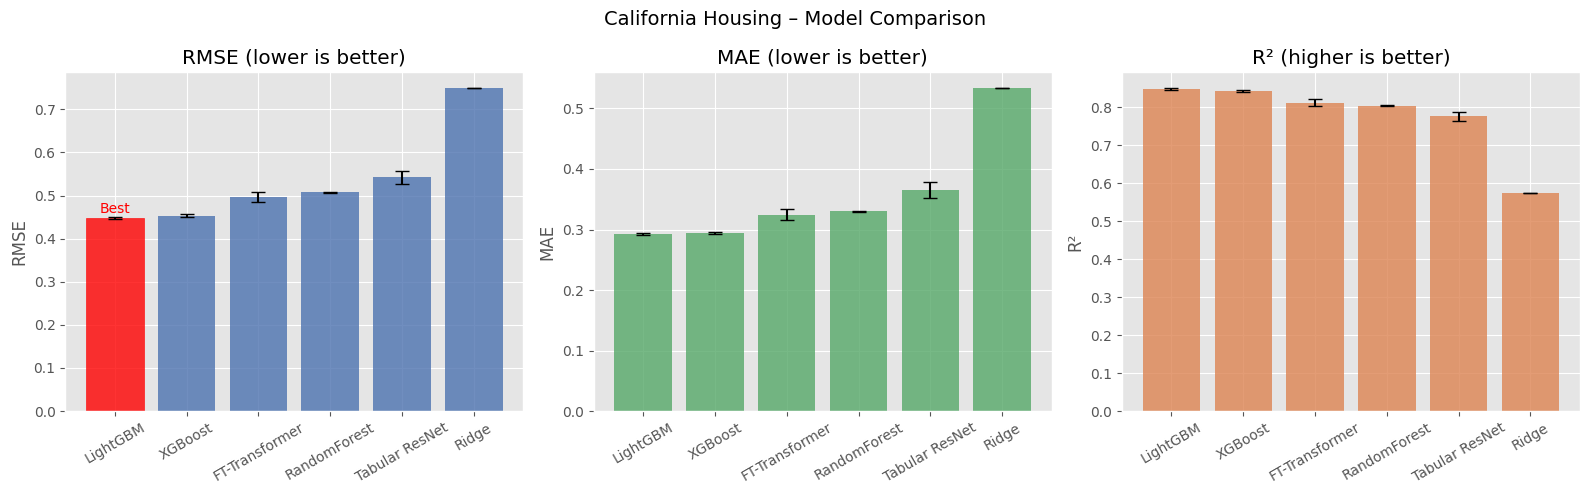

In [38]:
# RMSE, MAE, R2 visualizations
methods = summary.index.tolist()
rmse_means = summary['rmse_mean'].values
rmse_stds  = summary['rmse_std'].values

plt.style.use("ggplot")

# Performance plot
methods_perf = [m for m in methods if m in summary.index]
summary_plot = summary.loc[methods_perf]

color_rmse = "#4C72B0"
color_mae = "#55A868"
color_r2  = "#DD8452"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars_rmse = axes[0].bar(methods, summary['rmse_mean'].values, yerr=summary['rmse_std'].values,
            capsize=5, color=color_rmse, alpha=0.8)
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

bars_mae = axes[1].bar(methods, summary['mae_mean'].values, yerr=summary['mae_std'].values,
            capsize=5, color=color_mae, alpha=0.8)
axes[1].set_title('MAE (lower is better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=30)

bars_r2 = axes[2].bar(methods, summary['r2_mean'].values, yerr=summary['r2_std'].values,
            capsize=5, color=color_r2, alpha=0.8)
axes[2].set_title('R² (higher is better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=30)

best_idx = summary['rmse_mean'].idxmin()
best_pos = summary.index.get_loc(best_idx)
bars_rmse[best_pos].set_color('red')

offset = 0.01 * summary_plot["rmse_mean"].min()
axes[0].text(
    best_pos,
    summary_plot.loc[best_idx, "rmse_mean"] + offset,
    "Best",
    ha="center",
    va="bottom",
    color="red",
    fontsize=10
)

plt.suptitle('California Housing – Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


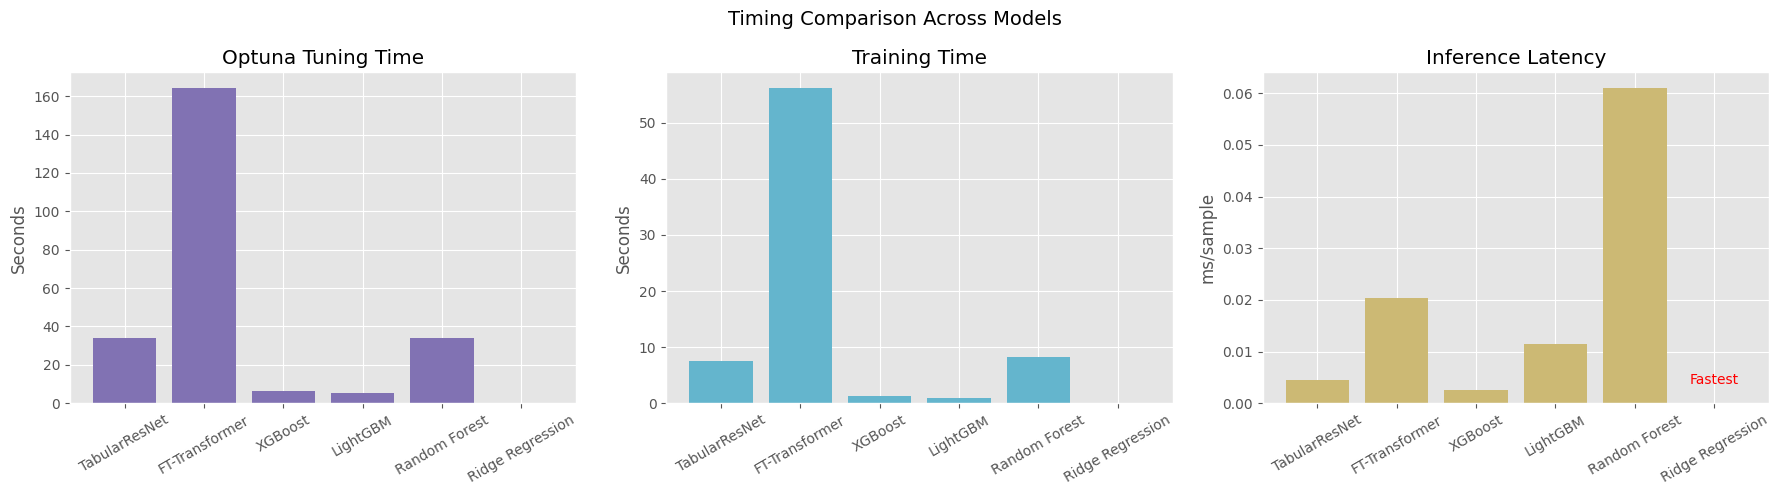

In [39]:
# Timing visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

methods = df_time_summary["method"]

# Computational cost plot
methods_time = [m for m in methods if m in df_time_summary["method"].values]
df_time_plot = (
    df_time_summary.set_index("method")
    .loc[methods_time]
    .reset_index()
)

color_optuna = "#8172B3"
color_train = "#64B5CD"
color_latency = "#CCB974"

# Optuna tuning time
axes[0].bar(
    df_time_plot["method"],
    df_time_plot["optuna_time"],
    color=color_optuna
)
axes[0].set_title("Optuna Tuning Time")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)

# Training time
axes[1].bar(
    df_time_plot["method"],
    df_time_plot["train_time"],
    color=color_train
)
axes[1].set_title("Training Time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=30)

# Inference latency
bars_latency = axes[2].bar(
    df_time_plot["method"],
    df_time_plot["Latency (ms/sample)"],
    color=color_latency
)
axes[2].set_title("Inference Latency")
axes[2].set_ylabel("ms/sample")
axes[2].tick_params(axis="x", rotation=30)

best_latency_idx = df_time_plot["Latency (ms/sample)"].idxmin()
best_latency_pos = df_time_plot.index.get_loc(best_latency_idx)
bars_latency[best_latency_pos].set_color("red")

offset = 0.05 * df_time_plot["Latency (ms/sample)"].max()
axes[2].text(
    best_latency_pos,
    df_time_plot.loc[best_latency_idx, "Latency (ms/sample)"] + offset,
    "Fastest",
    ha="center",
    va="bottom",
    color="red",
    fontsize=10
)

plt.suptitle("Timing Comparison Across Models", fontsize=14)
plt.tight_layout()
plt.show()

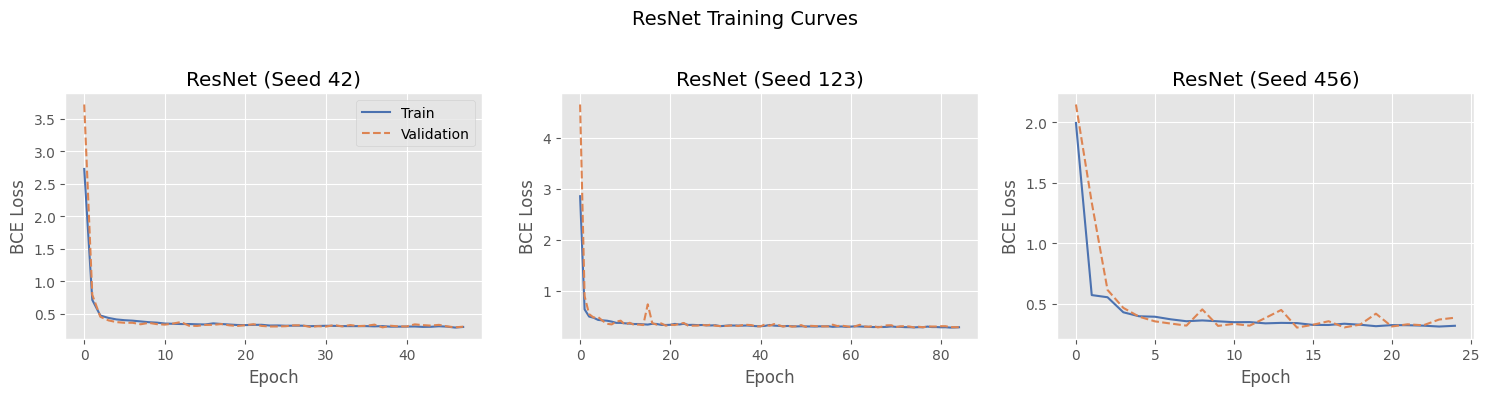

In [40]:
plt.style.use("ggplot")

fig, axes = plt.subplots(1, len(SEEDS), figsize=(5 * len(SEEDS), 4), sharex=False)

if len(SEEDS) == 1:
    axes = [axes]

for i, seed in enumerate(SEEDS):
    ax = axes[i]

    if seed in resnet_train_curves:
        tr_l, va_l = resnet_train_curves[seed]

        ax.plot(tr_l, label="Train", color="#4C72B0", linewidth=1.5)
        ax.plot(va_l, label="Validation", color="#DD8452", linestyle="--", linewidth=1.5)

    ax.set_title(f"ResNet (Seed {seed})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")

axes[0].legend(loc="upper right")

fig.suptitle("ResNet Training Curves", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

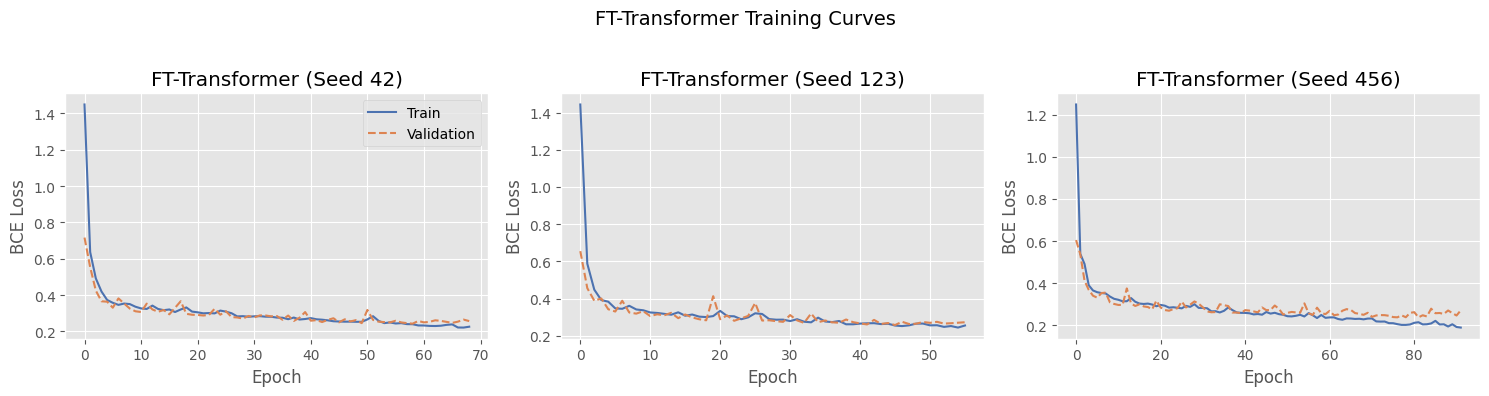

In [41]:
plt.style.use("ggplot")

fig, axes = plt.subplots(1, len(SEEDS), figsize=(5 * len(SEEDS), 4), sharex=False)

if len(SEEDS) == 1:
    axes = [axes]

for i, seed in enumerate(SEEDS):
    ax = axes[i]

    if seed in ft_train_curves:
        tr_l, va_l = ft_train_curves[seed]

        ax.plot(tr_l, label="Train", color="#4C72B0", linewidth=1.5)
        ax.plot(va_l, label="Validation", color="#DD8452", linestyle="--", linewidth=1.5)

    ax.set_title(f"FT-Transformer (Seed {seed})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")

axes[0].legend(loc="upper right")

fig.suptitle("FT-Transformer Training Curves", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

<Figure size 1000x600 with 0 Axes>

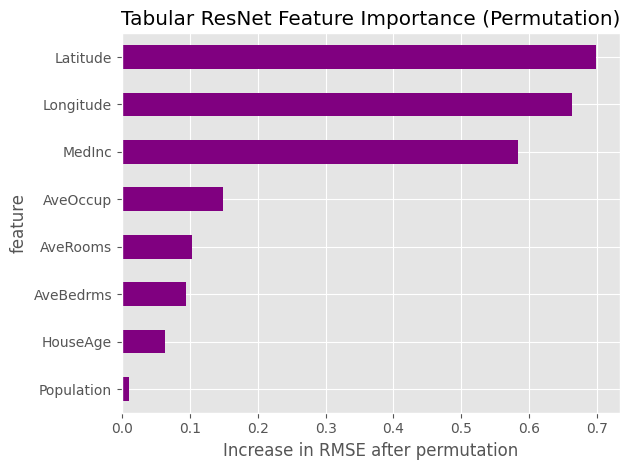

In [42]:
# Tabular ResNet feature importance via permutation importance
def resnet_permutation_importance(
    model,
    X,
    y,
    feature_names,
    device,
    n_repeats=5,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    base_preds = predict_dl_models_num(model, X, None, str(device))
    base_rmse  = np.sqrt(mean_squared_error(y, base_preds))

    importances = []

    for j, feat in enumerate(feature_names):
        deltas = []

        for _ in range(n_repeats):
            X_perm        = X.copy()
            X_perm[:, j]  = rng.permutation(X_perm[:, j])

            perm_preds = predict_dl_models_num(model, X_perm, None, str(device))
            perm_rmse  = np.sqrt(mean_squared_error(y, perm_preds))

            deltas.append(perm_rmse - base_rmse)

        importances.append({
            "feature":    feat,
            "importance": np.mean(deltas),
            "std":        np.std(deltas),
        })

    return pd.DataFrame(importances)

resnet_fi = resnet_permutation_importance(
    model=rn_model_last,
    X=X_test_sc,
    y=y_test,
    feature_names=feature_cols,
    device=device,
    n_repeats=5,
)
fi_all = resnet_fi.sort_values("importance")

plt.figure(figsize=(10, 6))
fi_all.plot.barh(
    x="feature",
    y="importance",
    legend=False,
    color="purple",
)
plt.title("Tabular ResNet Feature Importance (Permutation)")
plt.xlabel("Increase in RMSE after permutation")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

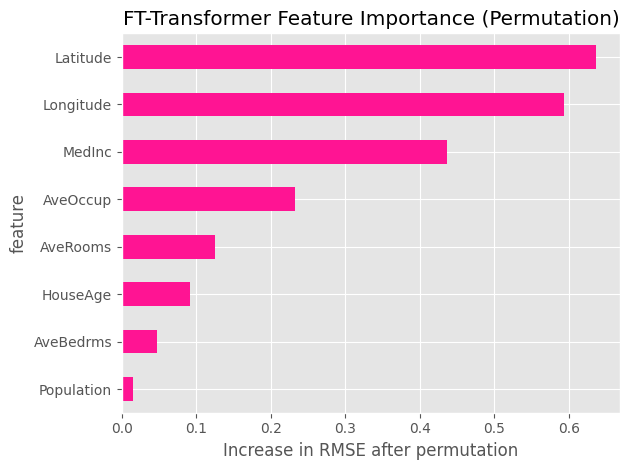

In [43]:
# FT-Transformer feature importance via permutation importance
def ft_permutation_importance(
    model,
    X,
    y,
    feature_names,
    device,
    n_repeats=5,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    base_preds = predict_dl_models_num(model, X, None, str(device))
    base_rmse  = np.sqrt(mean_squared_error(y, base_preds))

    importances = []

    for j, feat in enumerate(feature_names):
        deltas = []

        for _ in range(n_repeats):
            X_perm        = X.copy()
            X_perm[:, j]  = rng.permutation(X_perm[:, j])

            perm_preds = predict_dl_models_num(model, X_perm, None, str(device))
            perm_rmse  = np.sqrt(mean_squared_error(y, perm_preds))

            deltas.append(perm_rmse - base_rmse)

        importances.append({
            "feature":    feat,
            "importance": np.mean(deltas),
            "std":        np.std(deltas),
        })

    return pd.DataFrame(importances)

ft_fi = ft_permutation_importance(
    model=ft_model_last,
    X=X_test_sc,
    y=y_test,
    feature_names=feature_cols,
    device=device,
    n_repeats=5,
)
fi_all_ft = ft_fi.sort_values("importance")

plt.figure(figsize=(10, 6))
fi_all_ft.plot.barh(
    x="feature",
    y="importance",
    legend=False,
    color="deeppink",
)
plt.title("FT-Transformer Feature Importance (Permutation)")
plt.xlabel("Increase in RMSE after permutation")
plt.tight_layout()
plt.show()


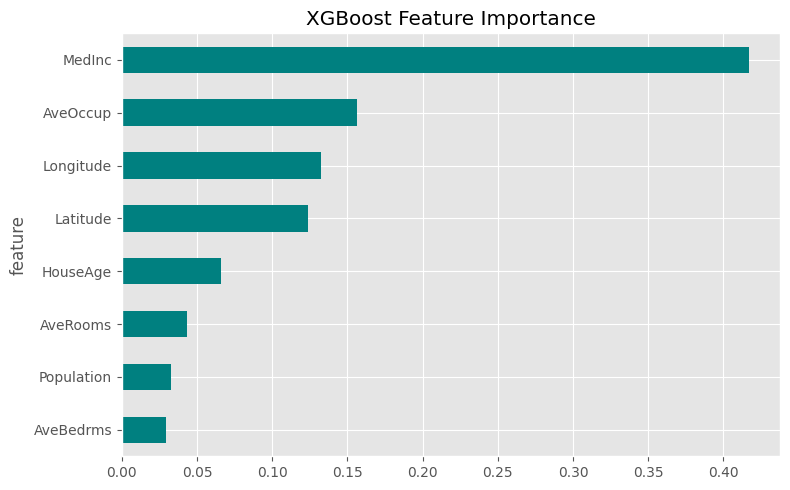

In [44]:
# XGBoost feature importance
if xgb_model_last is not None:
    fi = xgb_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='teal')
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.show()


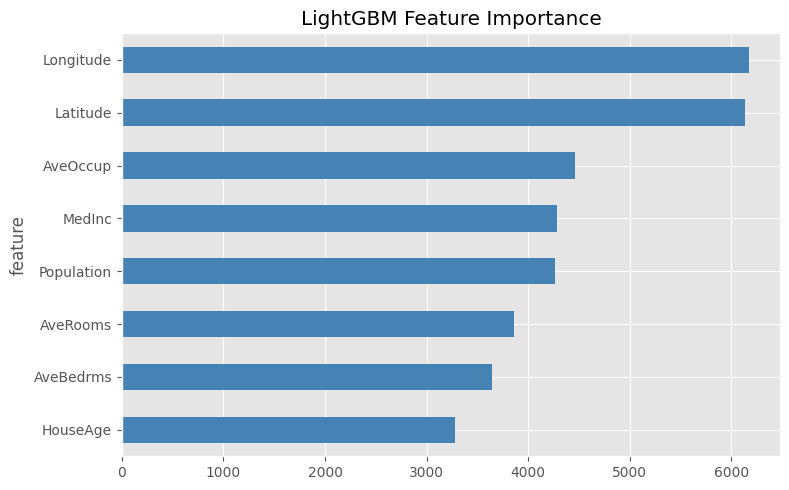

In [45]:
# LightGBM feature importance
if lgbm_model_last is not None:
    fi = lgbm_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='steelblue')
    plt.title('LightGBM Feature Importance')
    plt.tight_layout()
    plt.show()  

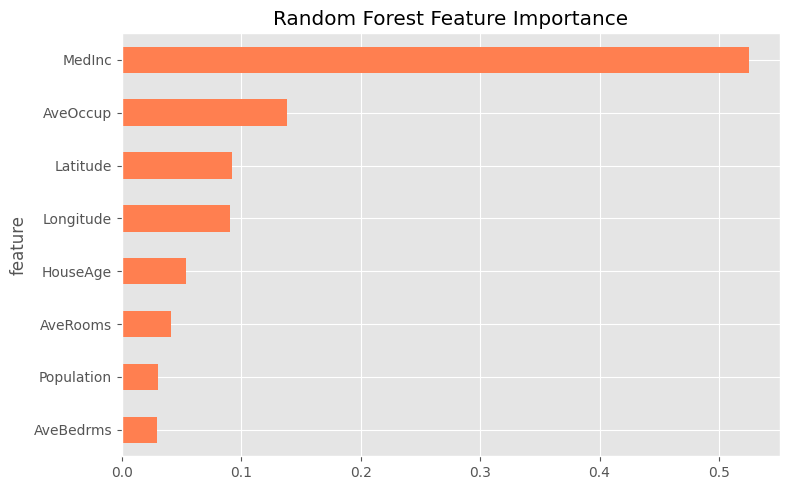

In [46]:
# Random Forest feature importance
if rf_model_last is not None:
    fi = rf_model_last.feature_importances_
    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': fi}).sort_values(
        'importance', ascending=True)
    fi_df.plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
                    color='coral')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()
